In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

print(f"TF  : {tf.__version__}")
print(f"GPU : {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-03-04 16:41:03.927470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772642464.117359      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772642464.176844      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772642464.636136      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772642464.636179      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772642464.636182      55 computation_placer.cc:177] computation placer alr

TF  : 2.19.0
GPU : True


In [2]:
# Load X and y from your first dataset (CWT notebook output)
CWT_DATA = '/kaggle/input/datasets/sangatichapla/mit-ecg-cwt/cwt_output' 

X_tr  = np.load(f'{CWT_DATA}/X_tr.npy')
X_val = np.load(f'{CWT_DATA}/X_val.npy')
X_te  = np.load(f'{CWT_DATA}/X_te.npy')
y_tr  = np.load(f'{CWT_DATA}/y_tr.npy')
y_val = np.load(f'{CWT_DATA}/y_val.npy')
y_te  = np.load(f'{CWT_DATA}/y_te.npy')

# Fix channel order
X_tr  = np.transpose(X_tr,  (0, 2, 3, 1))
X_val = np.transpose(X_val, (0, 2, 3, 1))
X_te  = np.transpose(X_te,  (0, 2, 3, 1))

print(f"X_tr : {X_tr.shape}")
print(f"y_tr : {y_tr.shape}")

# Load CNN features from your CNN dataset
CNN_DATA = '/kaggle/input/datasets/sangatichapla/mit-pretrained-cnn/cnn_features'

R_tr  = np.load(f'{CNN_DATA}/R_tr.npy')
R_val = np.load(f'{CNN_DATA}/R_val.npy')
R_te  = np.load(f'{CNN_DATA}/R_te.npy')
M_tr  = np.load(f'{CNN_DATA}/M_tr.npy')
M_val = np.load(f'{CNN_DATA}/M_val.npy')
M_te  = np.load(f'{CNN_DATA}/M_te.npy')

r_acc  = float(np.load(f'{CNN_DATA}/r_acc.npy'))
r_f1   = float(np.load(f'{CNN_DATA}/r_f1.npy'))
m_acc  = float(np.load(f'{CNN_DATA}/m_acc.npy'))
m_f1   = float(np.load(f'{CNN_DATA}/m_f1.npy'))
ft_acc = float(np.load(f'{CNN_DATA}/ft_acc.npy'))
ft_f1  = float(np.load(f'{CNN_DATA}/ft_f1.npy'))

from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.arange(5), y=y_tr)
cw      = dict(enumerate(weights))

CLASS_NAMES = ['Normal','PVC','APB','Paced','Fusion']

print(f"\nAll loaded!")
print(f"R_tr : {R_tr.shape}")
print(f"M_tr : {M_tr.shape}")
print(f"cw   : {cw}")

X_tr : (64766, 64, 64, 3)
y_tr : (64766,)

All loaded!
R_tr : (64766, 2048)
M_tr : (64766, 1280)
cw   : {0: np.float64(0.24665714557745405), 1: np.float64(2.595831663326653), 2: np.float64(7.268911335578002), 3: np.float64(2.6338348922326147), 4: np.float64(23.089483065953655)}


In [3]:
def to_sequence(features, seq_len=32):
    feat_dim  = features.shape[1]
    step_size = feat_dim // seq_len
    usable    = seq_len * step_size
    return features[:, :usable].reshape(-1, seq_len, step_size)

E_tr  = to_sequence(R_tr)
E_val = to_sequence(R_val)
E_te  = to_sequence(R_te)

seq_shape = E_tr.shape[1:]   # (32, 64)

print(f"Embedding shape : {E_tr.shape}")
print(f"  samples   : {E_tr.shape[0]}")
print(f"  timesteps : {E_tr.shape[1]}  (sequence length)")
print(f"  features  : {E_tr.shape[2]}  (per timestep)")
print(f"\nCNN features are now embeddings for RNN input")

Embedding shape : (64766, 32, 64)
  samples   : 64766
  timesteps : 32  (sequence length)
  features  : 64  (per timestep)

CNN features are now embeddings for RNN input


In [4]:

all_results = {}   

def train_and_eval(model, name, epochs=20):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.fit(
        E_tr, y_tr,
        validation_data=(E_val, y_val),
        epochs=epochs,
        batch_size=64,
        class_weight=cw,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=5, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(
                patience=3, factor=0.5, verbose=0)
        ],
        verbose=1
    )
    y_pred   = np.argmax(model.predict(E_te, verbose=0), axis=1)
    _, acc   = model.evaluate(E_te, y_te, verbose=0)
    f1       = f1_score(y_te, y_pred, average='macro', zero_division=0)

    # Store result
    all_results[name] = {'acc': acc, 'f1': f1, 'pred': y_pred}

    print(f"\n{name} => Accuracy: {acc:.4f}  Macro F1: {f1:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=CLASS_NAMES, zero_division=0))
    return acc, f1, y_pred

In [5]:
# SimpleRNN — basic recurrent model
# Problem: vanishing gradient for long sequences
# tanh activation squashes gradients → earlier timesteps forgotten

rnn_model = keras.Sequential([
    layers.Input(shape=seq_shape),
    layers.SimpleRNN(64, return_sequences=True, activation='tanh'),
    layers.Dropout(0.3),
    layers.SimpleRNN(64, return_sequences=False, activation='tanh'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='SimpleRNN')

rnn_model.summary()
rnn_acc, rnn_f1, rnn_pred = train_and_eval(rnn_model, 'SimpleRNN')

I0000 00:00:1772642561.443424      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772642561.449661      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,997 (82.02 KB)

 Trainable params: 20,997 (82.02 KB)

...

Epoch 1/20


I0000 00:00:1772642566.547306     129 service.cc:152] XLA service 0x7e3f9c00ad40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772642566.547342     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772642566.547346     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772642566.995793     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  25/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2266 - loss: 1.9067

I0000 00:00:1772642569.206409     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1012/1012 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4746 - loss: 0.9895 - val_accuracy: 0.8489 - val_loss: 0.4894 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7624 - loss: 0.5046 - val_accuracy: 0.8822 - val_loss: 0.4183 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8198 - loss: 0.4273 - val_accuracy: 0.8389 - val_loss: 0.5077 - learning_rate: 0.0010
Epoch 4/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8317 - loss: 0.3837 - val_accuracy: 0.7991 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8595 - loss: 0.3583 - val_accuracy: 0.9219 - val_loss: 0.2916 - learning_rate: 0.0010
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8460 - loss: 0.3565 - val_accuracy: 0.8863 - val_loss: 0.3507 - learning_rate: 0.0010
Epoch 7/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8728 - loss: 0.28

In [6]:
# LSTM — solves vanishing gradient with gates:
#   Forget gate : decides what to discard from memory
#   Input gate  : decides what new info to store
#   Output gate : decides what to output
#   Cell state  : long term memory across timesteps

lstm_model = keras.Sequential([
    layers.Input(shape=seq_shape),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='LSTM')

lstm_model.summary()
lstm_acc, lstm_f1, lstm_pred = train_and_eval(lstm_model, 'LSTM')

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,533 (275.52 KB)

 Trainable params: 70,533 (275.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5660 - loss: 0.8594 - val_accuracy: 0.7993 - val_loss: 0.5973 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8297 - loss: 0.4485 - val_accuracy: 0.7641 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8544 - loss: 0.3627 - val_accuracy: 0.8566 - val_loss: 0.4431 - learning_rate: 0.0010
Epoch 4/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8693 - loss: 0.3190 - val_accuracy: 0.8916 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8780 - loss: 0.3063 - val_accuracy: 0.8519 - val_loss: 0.4434 - learning_rate: 0.0010
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8936 - loss: 0.2551 - val_accuracy: 0.8998 - val_loss: 0.3428 - learning_rate: 0.0010
Epoch 7/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8886 - 

In [10]:
gru_model = keras.Sequential([
    layers.Input(shape=seq_shape),
    layers.GRU(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.GRU(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='GRU')

gru_acc, gru_f1, gru_pred = train_and_eval(gru_model, 'GRU')

Epoch 1/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5824 - loss: 0.8689 - val_accuracy: 0.8759 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8342 - loss: 0.4115 - val_accuracy: 0.8826 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8584 - loss: 0.3596 - val_accuracy: 0.9336 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 4/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8672 - loss: 0.3225 - val_accuracy: 0.9062 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8883 - loss: 0.2658 - val_accuracy: 0.8906 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8926 - loss: 0.2429 - val_accuracy: 0.9379 - val_loss: 0.2156 - learning_rate: 0.0010
Epoch 7/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8959 - 

In [7]:

def build_lstm_attention():
    inputs  = keras.Input(shape=seq_shape)

    # LSTM returns full sequence
    x       = layers.LSTM(64, return_sequences=True)(inputs)

    # Attention scores for each timestep
    score   = layers.Dense(1, activation='tanh')(x)      
    weight  = layers.Softmax(axis=1)(score)                
    context = layers.Multiply()([x, weight])               
    context = layers.Lambda(
                  lambda t: tf.reduce_sum(t, axis=1))(context)  # (B, 64)

    x       = layers.Dense(64, activation='relu')(context)
    x       = layers.Dropout(0.3)(x)
    output  = layers.Dense(5, activation='softmax')(x)

    return keras.Model(inputs, output, name='LSTM_Attention')

attn_model = build_lstm_attention()
attn_model.summary()
attn_acc, attn_f1, attn_pred = train_and_eval(attn_model, 'LSTM_Attention')

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 64)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32, 64)    │     33,024 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32, 1)     │         65 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 32, 1)     │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32, 64)    │          0 │ lstm_2[0][0],     │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 5)         │        325 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,574 (146.77 KB)

 Trainable params: 37,574 (146.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5881 - loss: 0.8679 - val_accuracy: 0.7786 - val_loss: 0.7492 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8282 - loss: 0.4365 - val_accuracy: 0.8740 - val_loss: 0.4212 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8516 - loss: 0.3580 - val_accuracy: 0.8568 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 4/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8673 - loss: 0.3083 - val_accuracy: 0.8790 - val_loss: 0.3969 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8807 - loss: 0.2765 - val_accuracy: 0.9333 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8878 - loss: 0.2531 - val_accuracy: 0.8493 - val_loss: 0.3828 - learning_rate: 0.0010
Epoch 7/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8974 - l

In [8]:


print("Hyperparameter Experimentation on LSTM")
print("Testing: LR=[1e-3, 1e-4]  BatchSize=[32, 128]\n")

hp_results = {}

for lr in [1e-3, 1e-4]:
    for bs in [32, 128]:
        key = f"lr={lr} bs={bs}"
        m = keras.Sequential([
            layers.Input(shape=seq_shape),
            layers.LSTM(64, return_sequences=True),
            layers.Dropout(0.3),
            layers.LSTM(64, return_sequences=False),
            layers.Dense(5, activation='softmax')
        ])
        m.compile(
            optimizer=keras.optimizers.Adam(lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        m.fit(
            E_tr, y_tr,
            validation_data=(E_val, y_val),
            epochs=10, batch_size=bs,
            class_weight=cw, verbose=0,
            callbacks=[keras.callbacks.EarlyStopping(
                patience=3, restore_best_weights=True)]
        )
        _, acc = m.evaluate(E_te, y_te, verbose=0)
        f1     = f1_score(y_te,
                     np.argmax(m.predict(E_te, verbose=0), axis=1),
                     average='macro', zero_division=0)
        hp_results[key] = {'acc': acc, 'f1': f1}
        print(f"  {key:<20} Accuracy={acc:.4f}  F1={f1:.4f}")

best = max(hp_results, key=lambda k: hp_results[k]['acc'])
print(f"\nBest config : {best}")
print(f"Best accuracy: {hp_results[best]['acc']:.4f}")

Hyperparameter Experimentation on LSTM
Testing: LR=[1e-3, 1e-4]  BatchSize=[32, 128]

  lr=0.001 bs=32       Accuracy=0.9236  F1=0.7664
  lr=0.001 bs=128      Accuracy=0.9295  F1=0.7930
  lr=0.0001 bs=32      Accuracy=0.8859  F1=0.7018
  lr=0.0001 bs=128     Accuracy=0.9190  F1=0.7386

Best config : lr=0.001 bs=128
Best accuracy: 0.9295


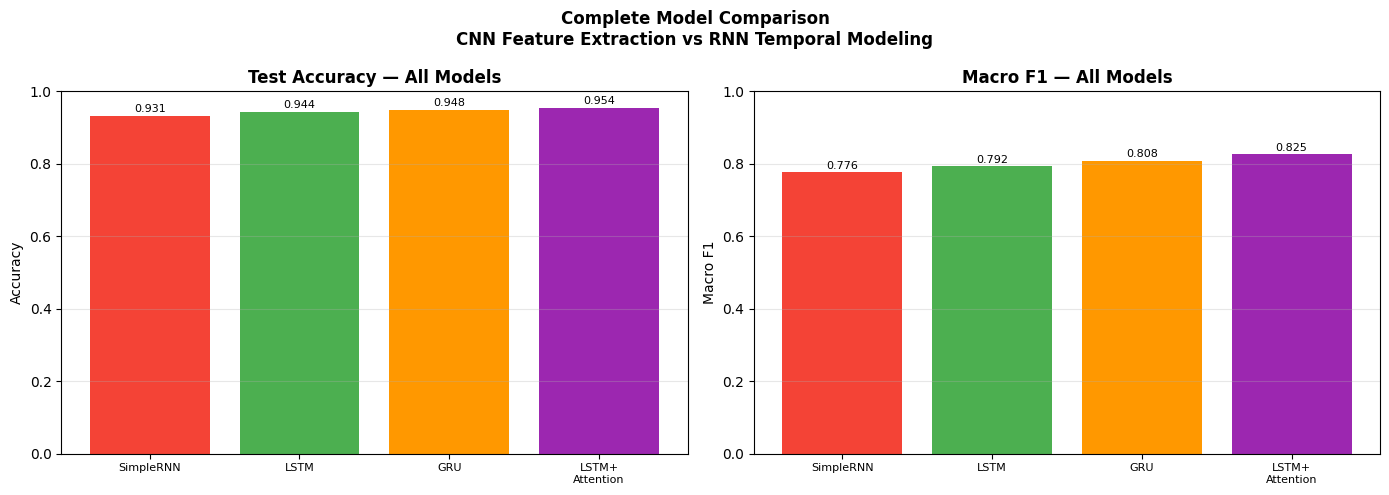


Model                    Accuracy   Macro F1
--------------------------------------------
  SimpleRNN            0.9313      0.7759
  LSTM                 0.9437      0.7922
  GRU                  0.9477      0.8084
  LSTM+ Attention      0.9540      0.8253


In [12]:
# Compare ALL models: CNN + RNN/LSTM/GRU + Attention

model_names = [
    'SimpleRNN',
    'LSTM',
    'GRU',
    'LSTM+\nAttention'
]
accs = [rnn_acc, lstm_acc, gru_acc, attn_acc]
f1s  = [rnn_f1,  lstm_f1,  gru_f1,  attn_f1]
colors = ['#F44336','#4CAF50','#FF9800','#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].bar(model_names, accs, color=colors)
axes[0].set_title('Test Accuracy — All Models', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', labelsize=8)
for i, v in enumerate(accs):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# F1
axes[1].bar(model_names, f1s, color=colors)
axes[1].set_title('Macro F1 — All Models', fontweight='bold')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', labelsize=8)
for i, v in enumerate(f1s):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Complete Model Comparison\nCNN Feature Extraction vs RNN Temporal Modeling',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Model':<22} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 44)
for n, a, f in zip(model_names, accs, f1s):
    n_clean = n.replace('\n', ' ')
    print(f"  {n_clean:<20} {a:.4f}      {f:.4f}")

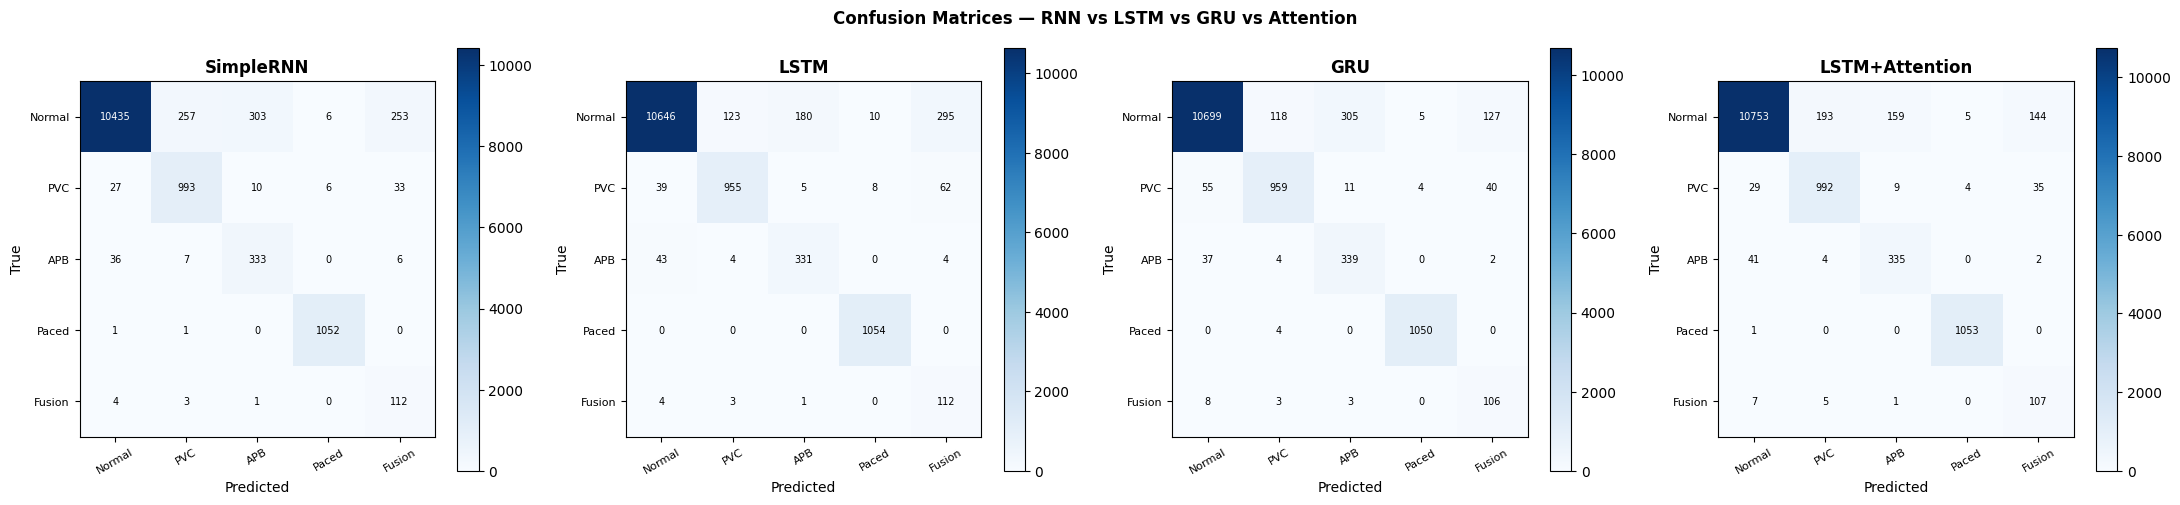

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, pred, title in zip(
    axes,
    [rnn_pred, lstm_pred, gru_pred, attn_pred],
    ['SimpleRNN', 'LSTM', 'GRU', 'LSTM+Attention']
):
    cm = confusion_matrix(y_te, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    fontsize=7,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('Confusion Matrices — RNN vs LSTM vs GRU vs Attention',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print(f"{'Model':<18} {'Layer':<30} {'Grad Norm':<12} Status")
print("-" * 72)

for model, name in [
    (rnn_model,  'SimpleRNN'),
    (lstm_model, 'LSTM'),
    (gru_model,  'GRU')
]:
    sample_x = tf.constant(E_tr[:32], dtype=tf.float32)
    sample_y = tf.constant(y_tr[:32], dtype=tf.int32)

    with tf.GradientTape() as tape:
        pred = model(sample_x, training=True)
        loss = tf.reduce_mean(
            keras.losses.sparse_categorical_crossentropy(sample_y, pred))

    grads = tape.gradient(loss, model.trainable_variables)

    for var, grad in zip(model.trainable_variables, grads):
        if grad is None: continue
        norm   = float(tf.norm(grad).numpy())
        status = ('VANISHING' if norm < 1e-4
                  else 'EXPLODING' if norm > 10
                  else 'healthy')
        layer  = var.name.split('/')[0]
        print(f"  {name:<16} {layer:<30} {norm:<12.6f} {status}")
    print()

Model              Layer                          Grad Norm    Status
------------------------------------------------------------------------
  SimpleRNN        kernel                         3.292574     healthy
  SimpleRNN        recurrent_kernel               1.405999     healthy
  SimpleRNN        bias                           0.152949     healthy
  SimpleRNN        kernel                         0.359366     healthy
  SimpleRNN        recurrent_kernel               0.296317     healthy
  SimpleRNN        bias                           0.057160     healthy
  SimpleRNN        kernel                         0.274499     healthy
  SimpleRNN        bias                           0.049351     healthy
  SimpleRNN        kernel                         0.769215     healthy
  SimpleRNN        bias                           0.121981     healthy

  LSTM             kernel                         0.593468     healthy
  LSTM             recurrent_kernel               0.128784     healthy
  LS